In [23]:
import os
from PIL import Image

def resize_images(input_folder, output_folder, size=(224, 224)):
    os.makedirs(output_folder, exist_ok=True)
    for filename in os.listdir(input_folder):
        if filename.endswith(('.jpg', '.png', '.jpeg')):
            img = Image.open(os.path.join(input_folder, filename))
            img = img.resize(size)
            img.save(os.path.join(output_folder, filename))

resize_images('dataset_raw/cable_present', 'dataset_raw/cable_present_resized')
resize_images('dataset_raw/cable_absent', 'dataset_raw/cable_absent_resized')


In [25]:
import os
from PIL import Image
from torchvision import transforms

def augment_images(input_folder, output_folder, num_augmented_images=3):
    os.makedirs(output_folder, exist_ok=True)
    
    # Définit les transformations
    augmentation = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),  # Flip horizontal
        transforms.RandomRotation(30),          # Rotation jusqu'à 30°
        transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Luminosité/contraste
        transforms.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),  # Recadrage
    ])

    for filename in os.listdir(input_folder):
        if filename.endswith(('.jpg', '.png', '.jpeg')):
            img_path = os.path.join(input_folder, filename)
            image = Image.open(img_path)

            # Sauvegarde l'image originale
            image.save(os.path.join(output_folder, filename))

            # Génère des images augmentées
            for i in range(num_augmented_images):
                augmented_image = augmentation(image)
                augmented_filename = f"{os.path.splitext(filename)[0]}_aug_{i}.jpg"
                augmented_image.save(os.path.join(output_folder, augmented_filename))

# Applique l'augmentation aux dossiers
augment_images('dataset_raw/cable_present', 'dataset_raw/cable_present')
augment_images('dataset_raw/cable_absent', 'dataset_raw/cable_absent')


In [26]:
import os
import shutil
from sklearn.model_selection import train_test_split

def split_dataset(input_folder, output_folder):
    os.makedirs(output_folder, exist_ok=True)
    for category in ['cable_present', 'cable_absent']:
        category_path = os.path.join(input_folder, category)
        images = [os.path.join(category_path, img) for img in os.listdir(category_path) if img.endswith(('.jpg', '.png', '.jpeg'))]
        train, temp = train_test_split(images, test_size=0.3, random_state=42)
        val, test = train_test_split(temp, test_size=0.5, random_state=42)

        for dataset, name in [(train, 'train'), (val, 'validation'), (test, 'test')]:
            dataset_path = os.path.join(output_folder, name, category)
            os.makedirs(dataset_path, exist_ok=True)
            for img in dataset:
                shutil.copy(img, dataset_path)

split_dataset('dataset_raw', 'dataset')


In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Transformation des images
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Redimensionnement à 224x224
    transforms.ToTensor(),          # Conversion en tenseur
    transforms.Normalize([0.5], [0.5])  # Normalisation (adaptée pour 1 canal ou 3 canaux)
])

# Chargement des datasets
train_dataset = datasets.ImageFolder('dataset/train', transform=data_transforms)
val_dataset = datasets.ImageFolder('dataset/validation', transform=data_transforms)
test_dataset = datasets.ImageFolder('dataset/test', transform=data_transforms)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Vérification
print(f"Nombre d'images dans le train : {len(train_dataset)}")
print(f"Nombre d'images dans la validation : {len(val_dataset)}")
print(f"Nombre d'images dans le test : {len(test_dataset)}")


c:\Users\33635\anaconda3\envs\surf\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Nombre d'images dans le train : 534
Nombre d'images dans la validation : 115
Nombre d'images dans le test : 115


### Model

In [ ]:
from torchvision import models
import torch.nn as nn

# Chargement de (ResNet18)
model = models.resnet18(pretrained=True)

# Remplacer la dernière couche pour correspondre à 2 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# Définir la perte et l'optimiseur
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


c:\Users\33635\anaconda3\envs\surf\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\33635\anaconda3\envs\surf\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [3]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    for epoch in range(num_epochs):
        model.train()  # Mode entraînement
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Époque {epoch+1}/{num_epochs}, Loss: {running_loss / len(train_loader)}")

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        print(f"Validation Loss: {val_loss / len(val_loader)}, Accuracy: {100 * correct / total:.2f}%")
    
    return model

# Lancer l'entraînement
model = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=20)


Époque 1/20, Loss: 0.7032038464265711
Validation Loss: 2.6614972352981567, Accuracy: 60.00%
Époque 2/20, Loss: 0.48325394181644216
Validation Loss: 0.46446823328733444, Accuracy: 81.74%
Époque 3/20, Loss: 0.3568241718937369
Validation Loss: 0.501934751868248, Accuracy: 76.52%
Époque 4/20, Loss: 0.3343016132712364
Validation Loss: 1.061703883111477, Accuracy: 73.04%
Époque 5/20, Loss: 0.2826310457552181
Validation Loss: 0.6447454579174519, Accuracy: 80.87%
Époque 6/20, Loss: 0.2246082306784742
Validation Loss: 0.26775432098656893, Accuracy: 92.17%
Époque 7/20, Loss: 0.14173773369368384
Validation Loss: 0.6060820743441582, Accuracy: 72.17%
Époque 8/20, Loss: 0.24819343778140404
Validation Loss: 0.9675985956564546, Accuracy: 78.26%
Époque 9/20, Loss: 0.24943441284053466
Validation Loss: 1.1210352890193462, Accuracy: 66.09%
Époque 10/20, Loss: 0.22876386870356166
Validation Loss: 0.3396726790815592, Accuracy: 84.35%
Époque 11/20, Loss: 0.1503174714744091
Validation Loss: 0.3753020199947059

In [8]:
def evaluate_model(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Accuracy on test data: {100 * correct / total:.2f}%")

# Évaluer le modèle
evaluate_model(model, test_loader)


Accuracy on test data: 89.57%


In [31]:
torch.save(model.state_dict(), 'cable_detector.pth')


In [32]:

from torchvision import models
import torch.nn as nn
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os


def load_model(model_path):
    # Charger un modèle ResNet18
    model = models.resnet18(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features, 2)  # 2 classes : câble présent ou absent
    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
    model.eval()  # Mettre le modèle en mode évaluation
    return model

model = load_model('cable_detector.pth')

# Transformations nécessaires
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Redimensionnement
    transforms.ToTensor(),          # Conversion en tenseur
    transforms.Normalize([0.5], [0.5])  # Normalisation
])

# Fonction pour effectuer une prédiction
def predict_image(image_path, model, class_names):
    # Charger et transformer l'image
    image = Image.open(image_path).convert('RGB')  # Charger en mode couleur
    transformed_image = data_transforms(image).unsqueeze(0)  # Ajouter une dimension batch
    
    # Faire la prédiction
    with torch.no_grad():
        outputs = model(transformed_image)
        _, predicted = torch.max(outputs, 1)
    
    # Retourner la classe prédite
    return class_names[predicted.item()]

# Afficher l'image et le résultat
def show_prediction(image_path, model, class_names):
    prediction = predict_image(image_path, model, class_names)
    
    # Afficher l'image
    image = Image.open(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Prédiction : {prediction}")
    plt.show()



c:\Users\33635\anaconda3\envs\surf\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\33635\anaconda3\envs\surf\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


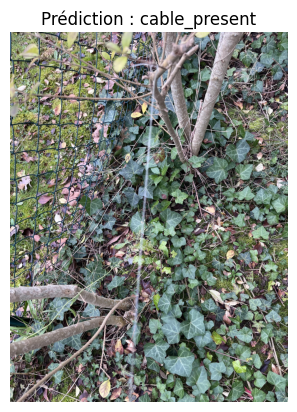

In [33]:
# Classes possibles
class_names = ['cable_absent', 'cable_present']

# Chemin vers une image de test
test_image_path = 'image test/image_test0.jpg'  # Remplace par le chemin d'une image

# Lancer la démonstration
show_prediction(test_image_path, model, class_names)
